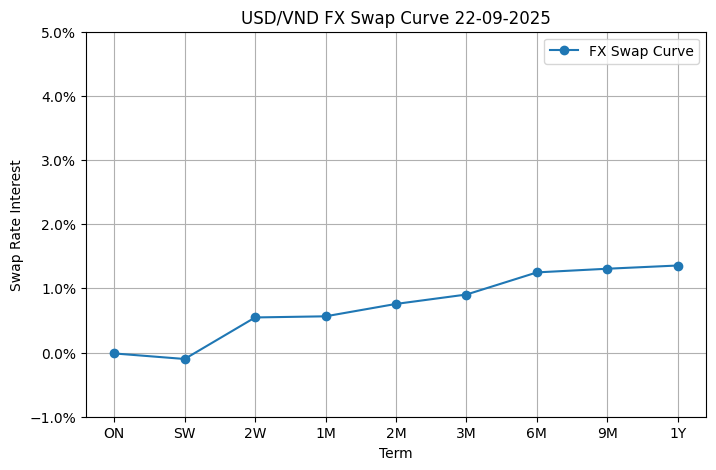

In [1]:
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime 


url1="https://www.investing.com/currencies/usd-vnd-forward-rates"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36","Accept-Language": "en-US,en;q=0.9"}
response1=requests.get(url1,headers=headers)
tables=pd.read_html(StringIO(response1.text))
df1=pd.DataFrame(tables[0])
today=(datetime.date.today()).strftime("%d-%m-%Y")


url2="https://www.24h.com.vn/ty-gia-ngoai-te-ttcb-c426.html"
response2=requests.get(url2,headers=headers)
tables=pd.read_html(StringIO(response2.text))
df2=pd.DataFrame(tables[2])


spotusd = int(float(str(df2.iloc[0, 1]).split()[0].replace(",", "")))


df1['forwardprice'] = df1["Bid"] + spotusd
df1['Days'] = [1,7,14,30,60,90,180,270,360]
df1['Term'] = ['ON','SW','2W','1M','2M','3M','6M','9M','1Y']
df1['Swap Rate'] = ((df1['forwardprice']-spotusd)/spotusd)/(df1['Days']/360) * 100  

plt.figure(figsize=(8,5))
plt.plot(df1['Term'], df1['Swap Rate'], marker="o", label="FX Swap Curve")
plt.xlabel("Term")
plt.ylabel("Swap Rate Interest")
plt.ylim(-1, 5)   
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter()) 
plt.title(f"USD/VND FX Swap Curve {today}")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
df1

,Unnamed: 0,Name,Bid,Ask,High,Low,Chg.,Time,forwardprice,Days,Term,Swap Rate
0,NaN,USDVND ON FWD,-0.01,0.01,-0.01,-0.22,0.14,21/09,26177.99,1,ON,-0.013752
1,NaN,USDVND SW FWD,-0.51,2.02,1.01,0.51,-0.51,19/09,26177.49,7,SW,-0.100193
2,NaN,USDVND 2W FWD,5.57,10.62,7.18,8.60,0.51,19/09,26183.57,14,2W,0.547133
3,NaN,USDVND 1M FWD,12.32,23.53,17.59,19.52,0.76,19/09,26190.32,30,1M,0.564749
4,NaN,USDVND 2M FWD,33.07,50.70,41.88,49.89,0.01,19/09,26211.07,60,2M,0.757965
5,NaN,USDVND 3M FWD,59.19,85.50,68.32,78.92,6.59,19/09,26237.19,90,3M,0.904424
6,NaN,USDVND 6M FWD,163.52,215.85,202.29,214.73,0.04,19/09,26341.52,180,6M,1.249293
7,NaN,USDVND 9M FWD,256.50,335.42,310.13,335.37,-19.67,19/09,26434.50,270,9M,1.306441
8,NaN,USDVND 1Y FWD,355.15,460.39,428.02,460.32,-14.09,19/09,26533.15,360,1Y,1.356674
